In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


In [6]:
df = pd.read_csv('Covid-19_svodnye.csv')

In [7]:
clearing_df = df.copy()
clearing_df.drop(1, inplace= True)
clearing_df.drop(0, inplace= True)
clearing_df = clearing_df.drop('COVID-19 (1-переболевшие, 0-здоровые)', axis = 1)
clearing_df = clearing_df.drop('Unnamed: 1', axis = 1)


In [8]:
sex = {'ж': 1, 'м': 2}
clearing_df['Unnamed: 2'] = clearing_df['Unnamed: 2'].replace(sex)
clearing_df = clearing_df.drop(15, axis = 0)

In [9]:
clearing_df = clearing_df.drop(['Unnamed: 3'], axis = 1)

In [10]:
cols = [f"Unnamed: {i}" for i in list(range(9, 14)) + list(range(15, 20))]
clearing_df[cols] = (
    clearing_df[cols]
    .replace(r"%", "", regex=True)
    .apply(pd.to_numeric, errors="coerce")
    .div(100)
)

In [11]:
clearing_df.columns = ['Пол', 'Кортизол', 'Глюкоза', 'Молочная к-та', 'Инсулин ', 'МДА (Эритроциты)', 'ФЛ(эр)', 'СХ(эр)', 'НЭЖК(эр)', 'ТГ(эр)','ЭХС(эр)', 'МДА (Плазма)', 'ФЛ(пл)', 'СХ(пл)','НЭЖК(пл)', 'ТГ(пл)', 'ЭХС(пл)', 'З/П']
columns_name = ['Пол', 'Кортизол', 'Глюкоза', 'Молочная к-та', 'Инсулин ', 'МДА (Эритроциты)', 'ФЛ(эр)', 'СХ(эр)', 'НЭЖК(эр)', 'ТГ(эр)','ЭХС(эр)', 'МДА (Плазма)', 'ФЛ(пл)', 'СХ(пл)','НЭЖК(пл)', 'ТГ(пл)', 'ЭХС(пл)']

In [12]:
clearing_df['Пол'] = clearing_df['Пол'].astype(float)
clearing_df['Кортизол'] = clearing_df['Кортизол'].astype(float)
clearing_df['Глюкоза'] = clearing_df['Глюкоза'].astype(float)
clearing_df['Молочная к-та'] = clearing_df['Молочная к-та'].astype(float)
clearing_df['Инсулин '] = clearing_df['Инсулин '].astype(float)
clearing_df['МДА (Эритроциты)'] = clearing_df['МДА (Эритроциты)'].astype(float)
clearing_df['МДА (Плазма)'] = clearing_df['МДА (Плазма)'].astype(float)
clearing_df['З/П'] = clearing_df['З/П'].astype(float)

In [13]:
scaler = MinMaxScaler()
for i in columns_name:
    clearing_df[i] = scaler.fit_transform(clearing_df[[i]])

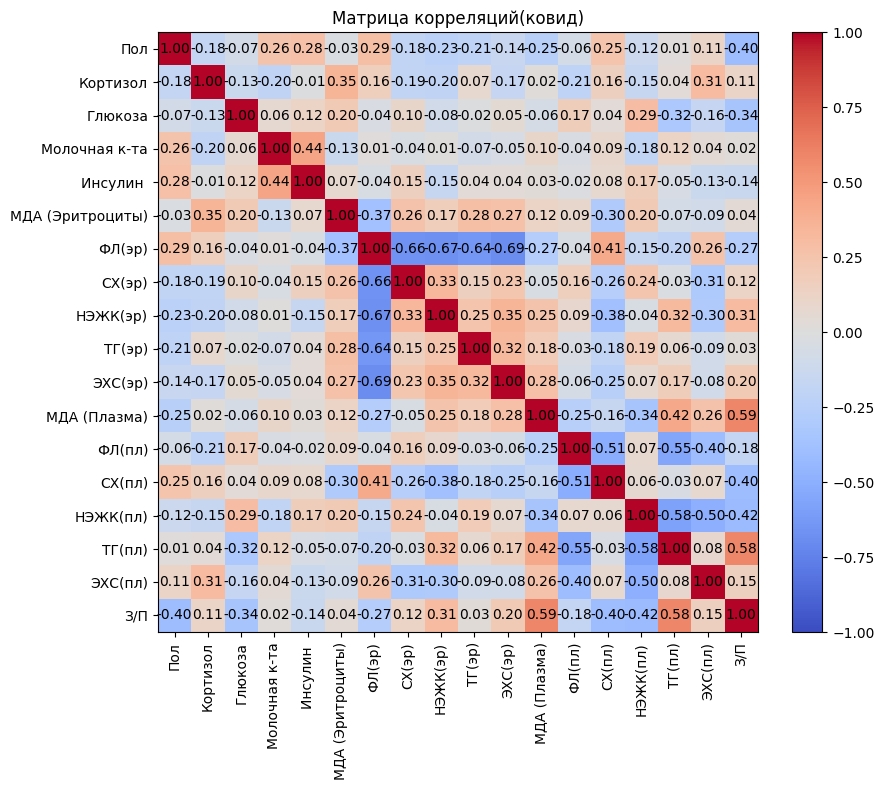

In [14]:
corr = clearing_df.select_dtypes(include="number").corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

# цифры в ячейках
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.title('Матрица корреляций(ковид)')
plt.tight_layout()
plt.show()



In [15]:
clearing_df.to_csv('clearing_df.csv', index= False)

In [16]:
clearing_df.info()

<class 'pandas.DataFrame'>
Index: 43 entries, 2 to 45
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Пол               43 non-null     float64
 1   Кортизол          43 non-null     float64
 2   Глюкоза           43 non-null     float64
 3   Молочная к-та     43 non-null     float64
 4   Инсулин           43 non-null     float64
 5   МДА (Эритроциты)  43 non-null     float64
 6   ФЛ(эр)            43 non-null     float64
 7   СХ(эр)            43 non-null     float64
 8   НЭЖК(эр)          43 non-null     float64
 9   ТГ(эр)            43 non-null     float64
 10  ЭХС(эр)           43 non-null     float64
 11  МДА (Плазма)      43 non-null     float64
 12  ФЛ(пл)            43 non-null     float64
 13  СХ(пл)            43 non-null     float64
 14  НЭЖК(пл)          43 non-null     float64
 15  ТГ(пл)            43 non-null     float64
 16  ЭХС(пл)           43 non-null     float64
 17  З/П            